In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

Task-**1**

In [3]:
# Step 1: Download dataset from Kaggle (if not already downloaded)
if not os.path.exists("fer2013.csv"):
    os.system("pip install kaggle")
    os.system("mkdir -p ~/.kaggle")
    os.system("cp kaggle.json ~/.kaggle/")
    os.system("chmod 600 ~/.kaggle/kaggle.json")

    # Download dataset
    os.system("kaggle datasets download -d ninamustwin/fer2013")

    # Extract dataset
    with zipfile.ZipFile("fer2013.zip", "r") as zip_ref:
        zip_ref.extractall()
    print("Dataset downloaded and extracted.")

# Step 2: Load the CSV file
data = pd.read_csv("fer2013.csv")

Dataset downloaded and extracted.


In [4]:
# Step 3: Preprocessing function
class FER2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get label and pixel values
        label = int(self.dataframe.iloc[idx]["emotion"])
        pixels = np.array(self.dataframe.iloc[idx]["pixels"].split(), dtype=np.uint8).reshape(48, 48)

        # Convert to PIL Image
        image = Image.fromarray(pixels)

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
# Step 4: Define transformations (Normalization & Augmentation)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure grayscale
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1,1]
])


In [6]:
# Step 5: Split dataset into training and test sets
train_df = data[data["Usage"] == "Training"]
test_df = data[data["Usage"] == "PublicTest"]

train_dataset = FER2013Dataset(train_df, transform=transform)
test_dataset = FER2013Dataset(test_df, transform=transform)

# Step 6: Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 28709
Testing samples: 3589


Task-**2**

In [7]:
from torch.utils.data import random_split

# Define split ratio
train_ratio = 0.8
val_ratio = 0.2
total_train_samples = len(train_dataset)

# Calculate number of samples for each split
train_size = int(train_ratio * total_train_samples)
val_size = total_train_samples - train_size  # Ensures total remains the same

# Perform random split
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Print dataset sizes
print(f"Training samples: {train_size}")
print(f"Validation samples: {val_size}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 22967
Validation samples: 5742
Test samples: 3589


Task-**3**

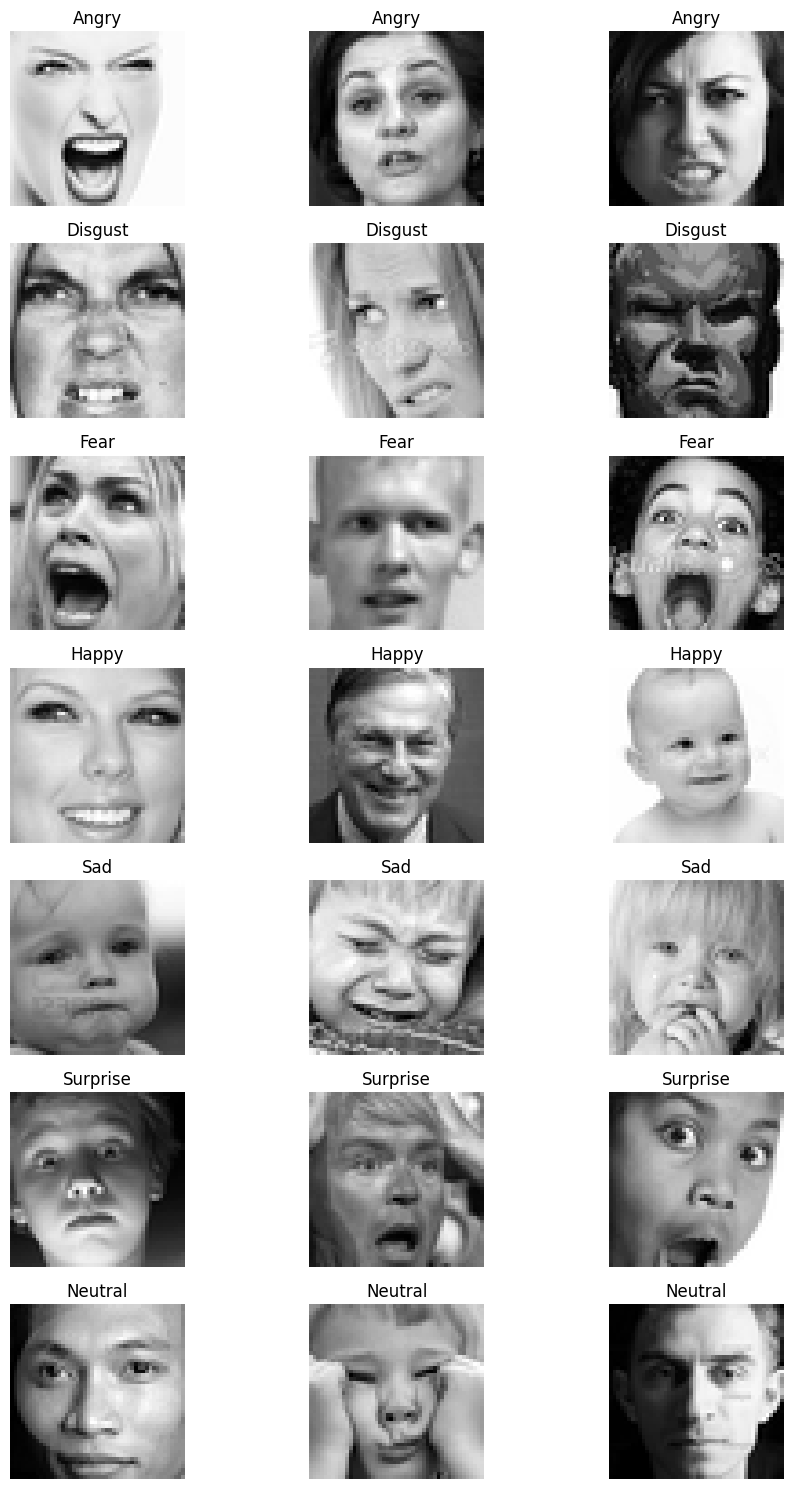

In [8]:
import matplotlib.pyplot as plt

# Get unique class labels
class_labels = {
    0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy",
    4: "Sad", 5: "Surprise", 6: "Neutral"
}

# Function to visualize 3 random samples per class
def visualize_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(len(class_labels), num_samples, figsize=(10, 15))

    for class_id, class_name in class_labels.items():
        # Find all indices belonging to the current class
        class_indices = [i for i in range(len(dataset)) if dataset[i][1] == class_id]

        # Select 3 random samples
        selected_indices = np.random.choice(class_indices, num_samples, replace=False)

        for j, idx in enumerate(selected_indices):
            image, label = dataset[idx]
            image = image.squeeze(0).numpy()  # Convert tensor to numpy for display

            axes[class_id, j].imshow(image, cmap="gray")
            axes[class_id, j].axis("off")
            axes[class_id, j].set_title(f"{class_name}")

    plt.tight_layout()
    plt.show()

# Call the function to visualize training samples
visualize_samples(train_dataset)


Task-4

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [10]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN, self).__init__()

        # First Convolutional Block
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)  # Batch Normalization
        self.residual1 = nn.Conv2d(1, 32, kernel_size=1, stride=1)  # Residual connection

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.residual2 = nn.Conv2d(32, 64, kernel_size=1, stride=1)  # Residual connection

        # Global Average Pooling (GAP)
        self.gap = nn.AdaptiveAvgPool2d(1)  # Converts (64, 48, 48) → (64, 1, 1)

        # 1x1 Convolutional Layer (Classification)
        self.conv1x1 = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        # First Convolutional Layer with Residual Connection
        identity1 = self.residual1(x)  # Skip connection
        x = F.relu(self.bn1(self.conv1(x)))
        x = x + identity1  # Add residual connection

        # Second Convolutional Layer with Residual Connection
        identity2 = self.residual2(x)  # Skip connection
        x = F.relu(self.bn2(self.conv2(x)))
        x = x + identity2  # Add residual connection

        # Global Average Pooling (GAP)
        x = self.gap(x)  # Shape → (batch, 64, 1, 1)

        # 1x1 Convolution for Classification
        x = self.conv1x1(x)  # Shape → (batch, 7, 1, 1)

        # Remove extra dimensions
        x = x.squeeze(-1).squeeze(-1)  # Shape → (batch, 7)

        # Apply Softmax for classification
        return F.log_softmax(x, dim=1)

# Instantiate Model
model = CustomCNN(num_classes=7)
print(model)

CustomCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (residual1): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (residual2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=1)
  (conv1x1): Conv2d(64, 7, kernel_size=(1, 1), stride=(1, 1))
)


In [11]:
import torch.optim as optim
import matplotlib.pyplot as plt

# Define device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to device
model.to(device)

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()  # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Learning rate = 1 × 10⁻³

# Training parameters
num_epochs = 20  # Can be tuned further
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move to GPU if available

        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        running_train_loss += loss.item() * images.size(0)

    # Compute average training loss
    avg_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation loop
    model.eval()  # Set model to evaluation mode
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)

    # Compute average validation loss
    avg_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    # Print loss for this epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Using device: cuda
Epoch [1/20], Train Loss: 1.7779, Val Loss: 1.7655
Epoch [2/20], Train Loss: 1.7579, Val Loss: 1.7502
Epoch [3/20], Train Loss: 1.7485, Val Loss: 1.7381
Epoch [4/20], Train Loss: 1.7438, Val Loss: 1.7633
Epoch [5/20], Train Loss: 1.7401, Val Loss: 1.7327
Epoch [6/20], Train Loss: 1.7337, Val Loss: 1.7435
Epoch [7/20], Train Loss: 1.7275, Val Loss: 1.7242
Epoch [8/20], Train Loss: 1.7216, Val Loss: 1.7130
Epoch [9/20], Train Loss: 1.7199, Val Loss: 1.7189
Epoch [10/20], Train Loss: 1.7118, Val Loss: 1.7473
Epoch [11/20], Train Loss: 1.7084, Val Loss: 1.7074
Epoch [12/20], Train Loss: 1.7044, Val Loss: 1.7123
Epoch [13/20], Train Loss: 1.6992, Val Loss: 1.7041
Epoch [14/20], Train Loss: 1.6939, Val Loss: 1.6924
Epoch [15/20], Train Loss: 1.6953, Val Loss: 1.6881
Epoch [16/20], Train Loss: 1.6876, Val Loss: 1.7225
Epoch [17/20], Train Loss: 1.6848, Val Loss: 1.6804
Epoch [18/20], Train Loss: 1.6800, Val Loss: 1.7007
Epoch [19/20], Train Loss: 1.6749, Val Loss: 1.6934
Ep

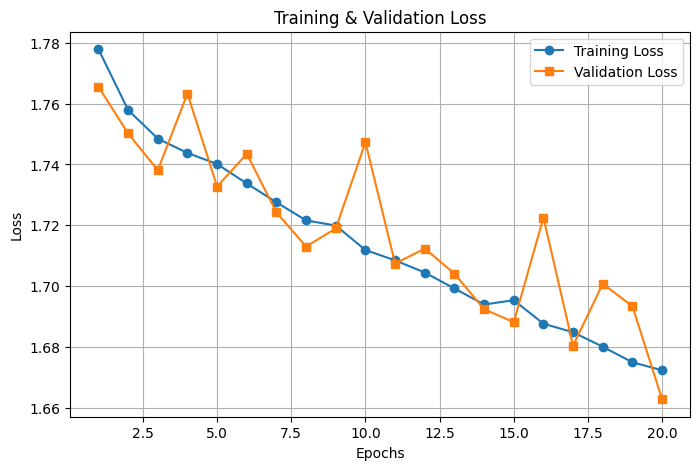

In [12]:
# Plot Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss", marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

Task-**6**

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns

In [14]:
# Set model to evaluation mode
model.eval()

CustomCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (residual1): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (residual2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=1)
  (conv1x1): Conv2d(64, 7, kernel_size=(1, 1), stride=(1, 1))
)

In [15]:
# Store predictions and true labels
all_preds = []
all_labels = []

# Disable gradient computation during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        _, preds = torch.max(outputs, 1)  # Get predicted class (argmax)

        # Store predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert lists to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute Evaluation Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")  # Weighted for class imbalance
recall = recall_score(all_labels, all_preds, average="weighted")  # Weighted for class imbalance
conf_matrix = confusion_matrix(all_labels, all_preds)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# Print Metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.3410
Precision: 0.3065
Recall: 0.3410


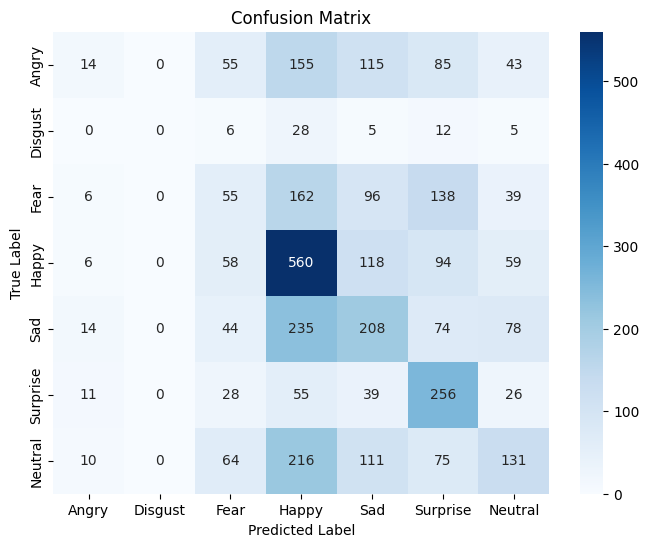

In [17]:
# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels.values(), yticklabels=class_labels.values())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**Task-7**

In [18]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

In [19]:
# Select a sample from each class
def get_random_samples(dataset, num_classes=7):
    class_samples = {i: None for i in range(num_classes)}

    for idx in range(len(dataset)):
        image, label = dataset[idx]
        if class_samples[label] is None:
            class_samples[label] = (image, label)

        if all(class_samples.values()):
            break

    return list(class_samples.values())

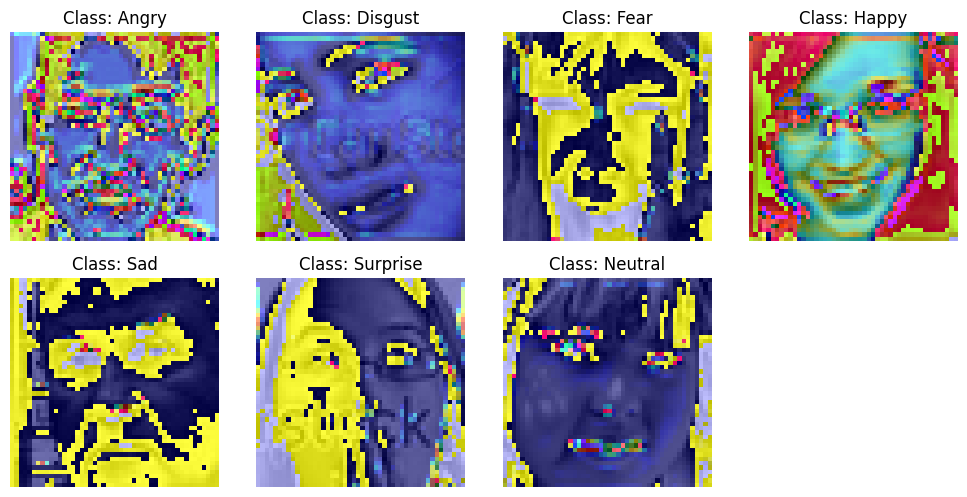

In [21]:
# Grad-CAM Implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to capture gradients and activations
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output  # Save the output of the convolutional layer

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]  # Save gradients during backpropagation

    def generate_cam(self, image_tensor, class_idx):
        image_tensor = image_tensor.unsqueeze(0).to(device)  # Add batch dimension
        self.model.eval()

        # Forward pass
        output = self.model(image_tensor)
        self.model.zero_grad()

        # Compute gradient for target class
        target = output[0, class_idx]
        target.backward()

        # Compute CAM
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)  # Global average pooling over gradients
        cam = torch.sum(weights * self.activations, dim=1).squeeze().cpu().detach().numpy()

        # Normalize CAM
        cam = np.maximum(cam, 0)  # ReLU to remove negative values
        cam = cam / np.max(cam)  # Normalize to [0,1]

        return cam

# Initialize Grad-CAM for the second conv layer
grad_cam = GradCAM(model, model.conv2)

# Get random samples (one per class)
samples = get_random_samples(test_dataset)

# Plot Grad-CAM results
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(samples):
    image_np = image.squeeze(0).numpy()  # Convert tensor to NumPy
    cam = grad_cam.generate_cam(image, class_idx=label)

    # Resize CAM to match image size
    cam_resized = cv2.resize(cam, (48, 48))

    # Overlay CAM on image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    overlay = 0.5 * heatmap + 0.5 * np.dstack([image_np] * 3) * 255  # Blend with original image

    # Display results
    plt.subplot(4, 4, i + 1)
    plt.imshow(overlay.astype(np.uint8))
    plt.title(f"Class: {class_labels[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Task-8**

In [26]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

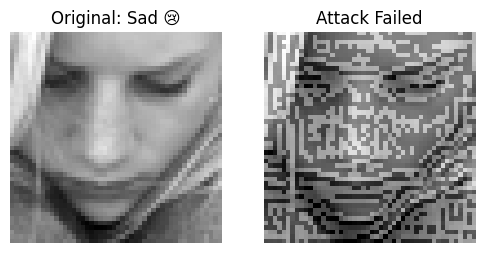

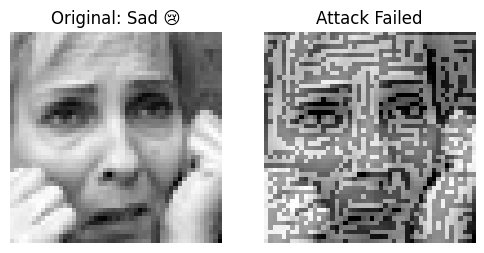

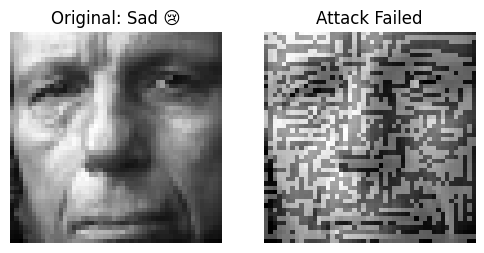

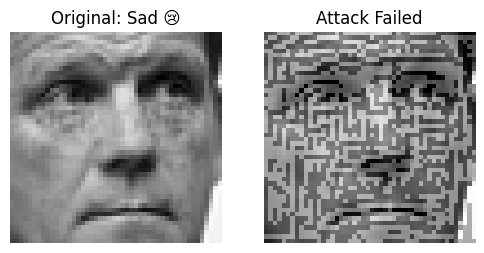

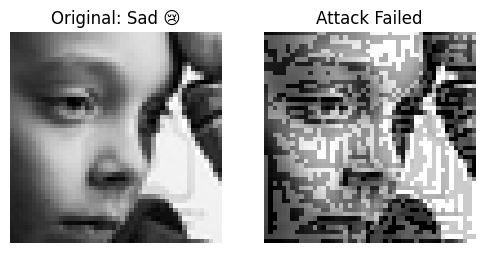

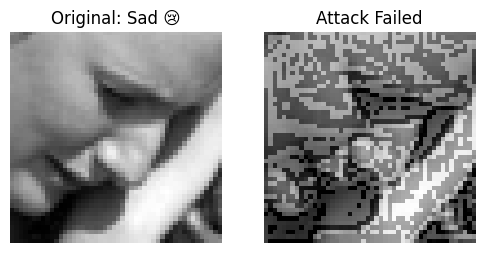

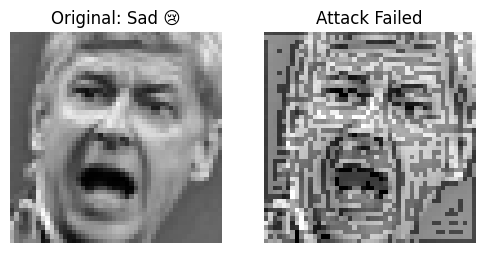

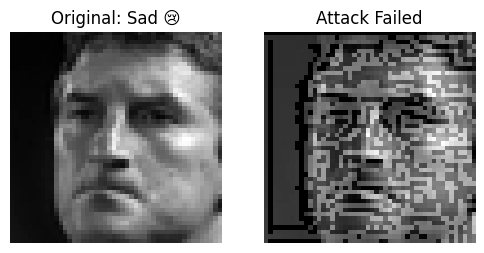

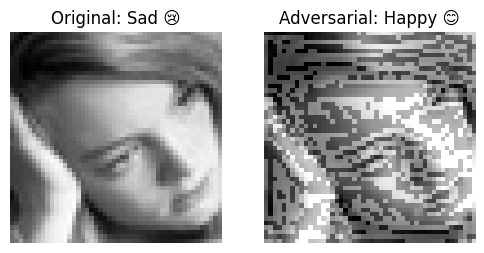

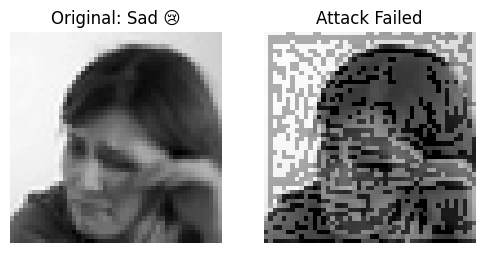

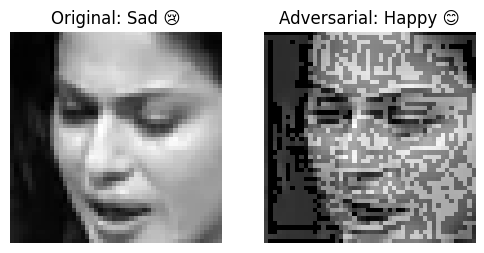

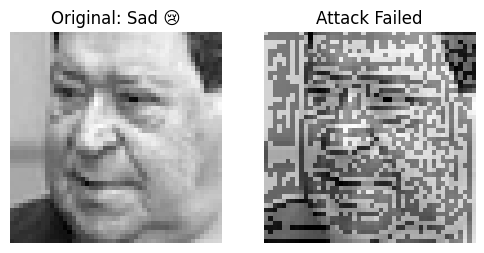

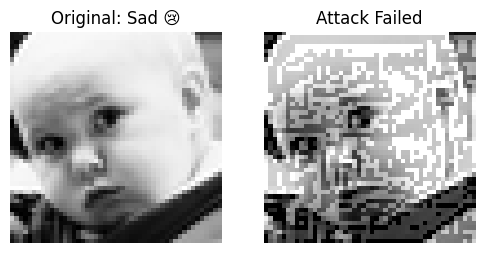

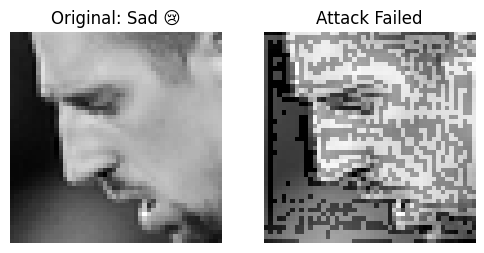

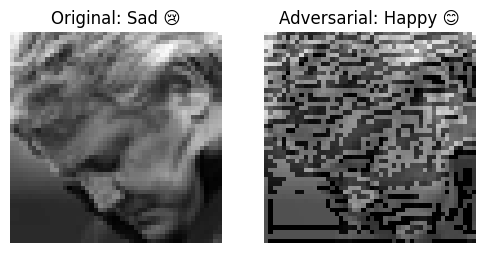

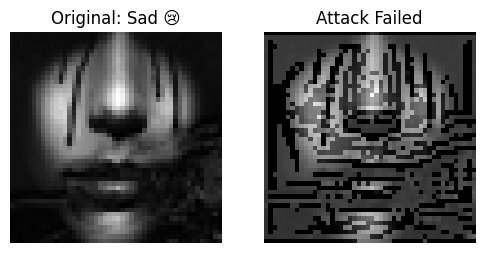

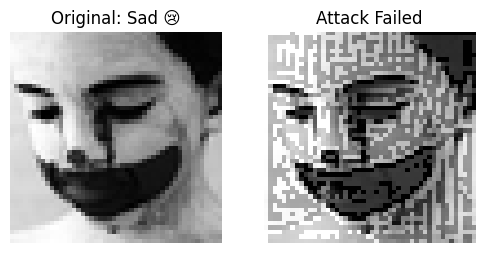

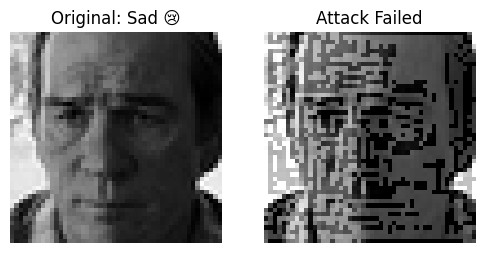

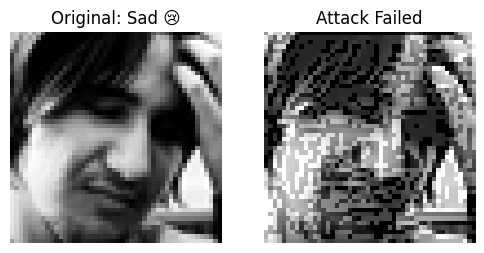

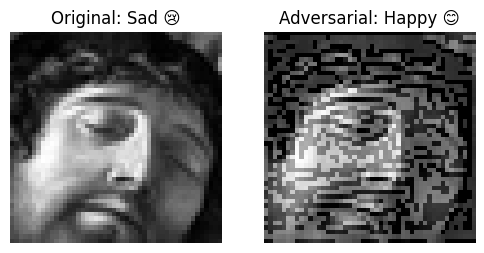

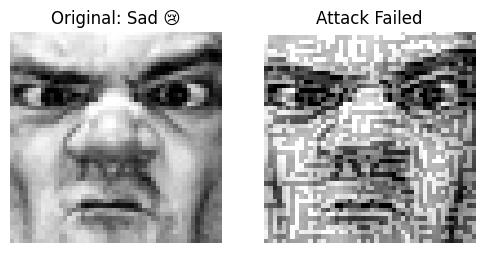

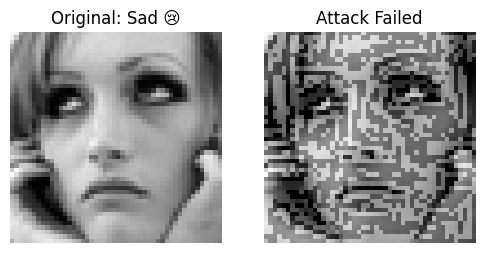

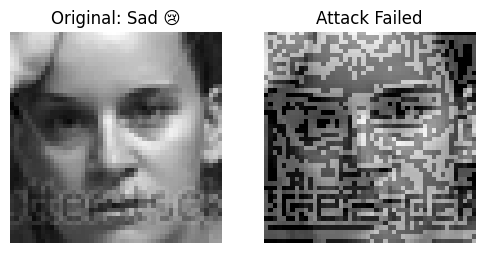

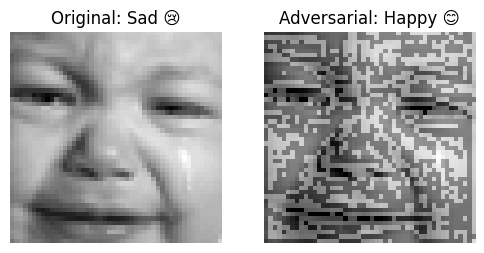

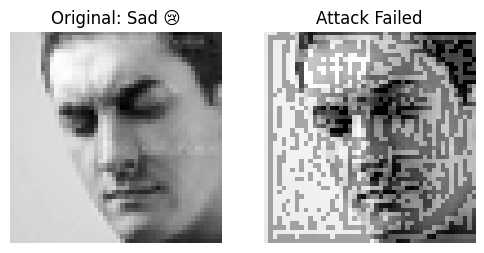

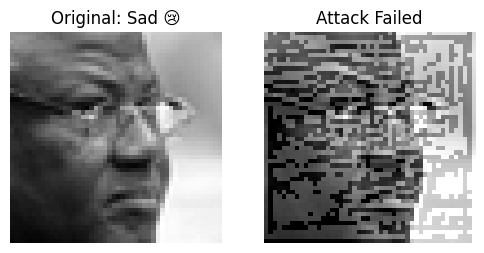

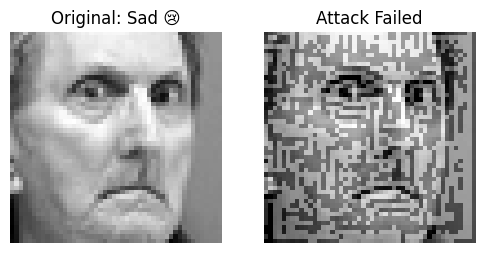

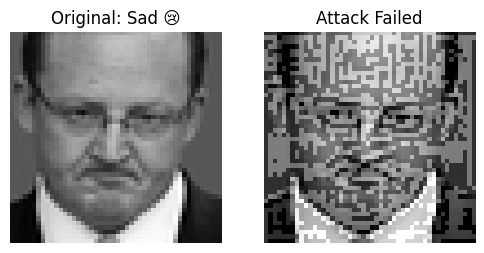

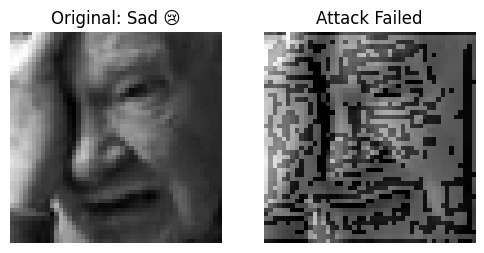

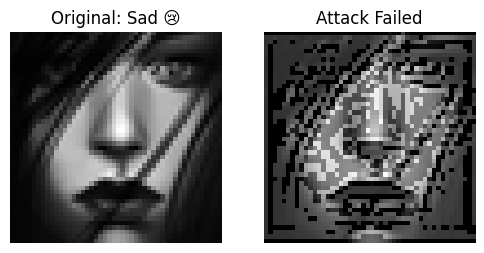

In [39]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Set epsilon for FGSM attack (tune this value)
epsilon = 0.3  # Try 0.1, 0.2, 0.3, etc.

# Set model to evaluation mode
model.eval()

# Track correctly classified "sad" images and successful attacks
num_correctly_classified_sad = 0
num_successful_attacks = 0

# Select "sad" class samples from test set
sad_indices = [i for i in range(len(test_dataset)) if test_dataset[i][1] == 4]  # Label 4 = "sad"

# Loop through selected "sad" samples
for idx in sad_indices:
    image, label = test_dataset[idx]  # Get image & label
    image = image.unsqueeze(0).to(device)  # Add batch dimension & move to GPU
    label = torch.tensor([label]).to(device)  # Convert label to tensor

    # Ensure requires_grad is True
    image.requires_grad = True  # ✅ FIXED: Enable gradient tracking

    # Forward pass (before attack)
    output = model(image)
    predicted_label = output.argmax(dim=1).item()

    # Check if the model originally classified as "sad"
    if predicted_label == 4:
        num_correctly_classified_sad += 1  # Count correctly classified "sad" images

        # Compute loss and gradients
        loss = F.nll_loss(output, label)
        model.zero_grad()
        loss.backward()

        # Ensure gradient exists before applying FGSM
        if image.grad is not None:
            # Generate adversarial image using FGSM
            sign_data_grad = image.grad.sign()  # ✅ FIXED: Use `.sign()` instead of `.data.sign()`
            perturbed_image = image + epsilon * sign_data_grad
            perturbed_image = torch.clamp(perturbed_image, -1, 1)  # Keep valid pixel range

            # Re-classify the perturbed image
            new_output = model(perturbed_image)
            new_pred = new_output.argmax(dim=1).item()

            # Check if attack was successful (misclassified as "happy" - label 3)
            if new_pred == 3:
                num_successful_attacks += 1

            # Visualize Original & Adversarial Image
            if num_successful_attacks <= 5:  # Show only 5 images for clarity
                original_image_np = image.squeeze(0).cpu().detach().numpy()
                perturbed_image_np = perturbed_image.squeeze(0).cpu().detach().numpy()

                plt.figure(figsize=(6, 3))

                plt.subplot(1, 2, 1)
                plt.imshow(original_image_np.squeeze(), cmap="gray")
                plt.title("Original: Sad 😢")
                plt.axis("off")

                plt.subplot(1, 2, 2)
                plt.imshow(perturbed_image_np.squeeze(), cmap="gray")
                plt.title("Adversarial: Happy 😊" if new_pred == 3 else "Attack Failed")
                plt.axis("off")

                plt.show()


In [40]:
# Calculate Success Rate
if num_correctly_classified_sad > 0:
    success_rate = (num_successful_attacks / num_correctly_classified_sad) * 100
else:
    success_rate = 0  # Avoid division by zero

# Print Attack Success Rate
print(f"FGSM Attack Success Rate: {success_rate:.2f}%")
print(f"Correctly classified 'Sad' images: {num_correctly_classified_sad}")
print(f"Misclassified as 'Happy': {num_successful_attacks}")


FGSM Attack Success Rate: 23.56%
Correctly classified 'Sad' images: 208
Misclassified as 'Happy': 49
